<a href="https://colab.research.google.com/github/jonkrohn/ML-foundations/blob/master/notebooks/regression-in-pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression in PyTorch

In this notebook, we use the PyTorch **automatic differentiation** library to fit a straight line to data points. Thus, here we use calculus to solve the same regression problem that we used the Moore-Penrose Pseudoinverse to solve in the [*Linear Algebra II* notebook](https://github.com/jonkrohn/ML-foundations/blob/master/notebooks/2-linear-algebra-ii.ipynb).

In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
# Some made up data
x = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7.]) # E.g.: Dosage of drug for treating Alzheimer's disease
x

tensor([0., 1., 2., 3., 4., 5., 6., 7.])

The $y$ values were created using the equation of a line $y = mx + b$. This way, we know what the model parameters to be learned are, say, $m = -0.5$ and $b = 2$. And then I added random, normally-distributed noise has been added to simulate sampling error because in the real world most processes, we will not have a perfect relationship between $x$ and $y$, there will be some random noise associated with our observation: 

Below commented cell generates target values y using a linear relationship 
y = −0.5x + 2 + adds random noise.

`torch.normal()` samples from a normal (Gaussian) distribution,

`mean=torch.zeros(8)` → mean = 0 for all 8 values, so that our noise is distributed evenly for our regression line

`std=0.2` → small spread (low noise)

Purpose: simulate real-world data where observations aren’t perfectly linear, making the model learn from noisy, realistic data instead of ideal values.

In [3]:
# y = -0.5*x + 2 + torch.normal(mean=torch.zeros(8), std=0.2)

For reproducibility of this demo, here's a fixed example of $y$ values obtained by running the commented-out line above: 

In [3]:
y = torch.tensor([1.86, 1.31, .62, .33, .09, -.67, -1.23, -1.37]) # E.g.: Patient's "forgetfulness score"
y

tensor([ 1.8600,  1.3100,  0.6200,  0.3300,  0.0900, -0.6700, -1.2300, -1.3700])

### Let's see relationship between $x$ and $y$ with some noise that we generated manually(in real world y values we will get by default will have some noise). Let's plot the graph between $x$ and $y$.

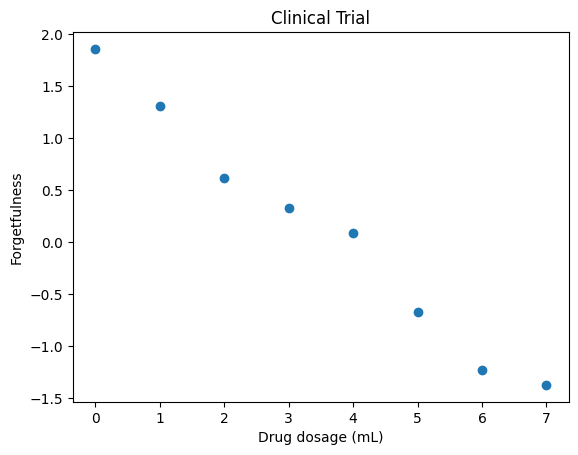

In [4]:
fig, ax = plt.subplots()
plt.title("Clinical Trial")
plt.xlabel("Drug dosage (mL)")
plt.ylabel("Forgetfulness")
_ = ax.scatter(x, y)

Initialize the slope parameter $m$ with a "random" value of 0.9...

(**N.B.**: In this simple demo, we could guess approximately-correct parameter values to start with. Or, we could use an algebraic (e.g., Moore-Penrose pseudoinverse) or statistical (e.g., ordinary-least-squares regression) to solve for the parameters quickly. This tiny machine learning demo with two parameters and eight data points scales, however, to millions of parameters and millions of data points. The other approaches -- guessing, algebra, statistics -- do not come close to scaling in this way.)

In [ ]:
m = torch.tensor([0.9]).requires_grad_() # OR OR OR you can write: m = torch.tensor([0.9], requires_grad=True)
m

tensor([0.9000], requires_grad=True)

Above line initializes the slope $m$ of your line $y=mx+b$ with a starting value 0.9 and enables gradient tracking.

$torch.tensor([0.9])$ → creates a tensor (parameter) with initial guess

`.requires_grad_()` → tells PyTorch to track all operations on m

Role: During training, PyTorch computes how changes in m affect the loss (error) using automatic differentiation. This gradient is then used to update m (via optimizers like gradient descent) to find the optimal slope that best fits the data.

...and do the same for the $y$-intercept parameter $b$: 

In [ ]:
b = torch.tensor([0.1]).requires_grad_() # OR OR OR you can write: b = torch.tensor([0.1], requires_grad=True)
b

tensor([0.1000], requires_grad=True)

In [7]:
def regression(my_x, my_m, my_b):
    return my_m*my_x + my_b

In [8]:
def regression_plot(my_x, my_y, my_m, my_b):
    
    fig, ax = plt.subplots()

    ax.scatter(my_x, my_y)
    
    x_min, x_max = ax.get_xlim()
    y_min = regression(x_min, my_m, my_b).detach().item()
    y_max = regression(x_max, my_m, my_b).detach().item()
    
    ax.set_xlim([x_min, x_max])
    _ = ax.plot([x_min, x_max], [y_min, y_max])

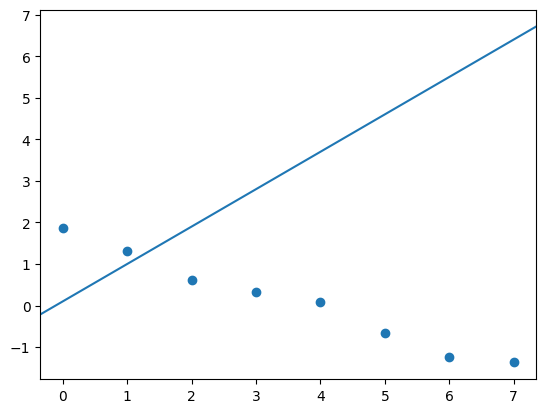

In [9]:
regression_plot(x, y, m, b)

**Return to slides here if following *Calculus I* class.**

### Machine Learning
In four easy steps :)

**Step 1**: Forward pass

In [10]:
yhat = regression(x, m, b)
yhat

tensor([0.1000, 1.0000, 1.9000, 2.8000, 3.7000, 4.6000, 5.5000, 6.4000],
       grad_fn=<AddBackward0>)

___
#### **Step 2**: Compare $\hat{y}$ with true $y$ to calculate cost $C$

There is a PyTorch `MSELoss` method, but let's define it outselves to see how it works. MSE cost is defined by: $$C = \frac{1}{n} \sum_{i=1}^n (\hat{y_i}-y_i)^2 $$

In [11]:

def mse(my_yhat, my_y): 
    sigma = torch.sum((my_yhat - my_y)**2)
    return sigma/len(my_y)

In [13]:
C = mse(yhat, y) # So, we pass yhat which is our estimated values which we calculated along with true values y to calculate the cost
C

tensor(19.6755, grad_fn=<DivBackward0>)

___
#### **Step 3**: Use autodiff to calculate gradient of $C$ w.r.t. parameters

In [14]:
C.backward()

In [15]:
m.grad

tensor([36.3050])

##### Since the slope is positive w.r.t. m, implies the m we took was bigger than what it's actual value should be thus we should decrease the value of m to reduce the cost. 

In [16]:
b.grad

tensor([6.2650])

##### Same goes for the b parameter. Positive slope implies positive relationship. So to reduce the cost we need to reduce the parameter b's value. 

##### Also we can see that slope is much larger for cost w.r.t. m compared to cost w.r.t. b, implies reduction in value of m will have much bigger impact on cost C compared to reduction in value of b.

___
### **Step 4**: Gradient descent

In [17]:
optimizer = torch.optim.SGD([m, b], lr=0.01)  ### SGD - Stochastic Gradient Descent. It accepts the list of all the model parameters as a list and a learning rate(lr) value which tells how much shall we adjust the parameters in each iteration.

In [18]:
optimizer.step()

Confirm parameters have been adjusted sensibly: 

In [19]:
m

tensor([0.5369], requires_grad=True)

In [20]:
b

tensor([0.0374], requires_grad=True)

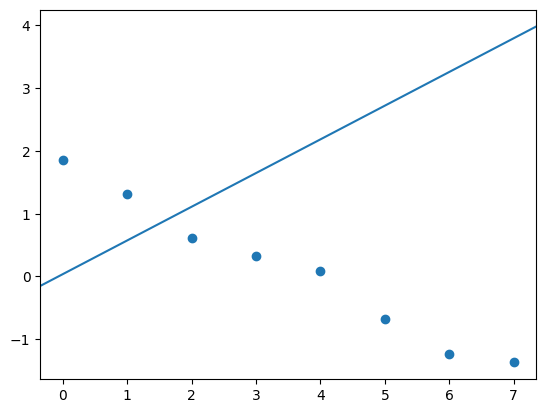

In [21]:
regression_plot(x, y, m, b)

We can repeat steps 1 and 2 to confirm cost has decreased: 

In [22]:
C = mse(regression(x, m, b), y)
C

tensor(8.5722, grad_fn=<DivBackward0>)

Put the 4 steps in a loop to iteratively minimize cost toward zero: 

In [23]:
epochs = 1000
for epoch in range(epochs):
    
    optimizer.zero_grad() # Reset gradients to zero; else they accumulate
    
    yhat = regression(x, m, b) # Step 1
    C = mse(yhat, y) # Step 2
    
    C.backward() # Step 3
    optimizer.step() # Step 4
    
    print('Epoch {}, cost {}, m grad {}, b grad {}'.format(epoch, '%.3g' % C.item(), '%.3g' % m.grad.item(), '%.3g' % b.grad.item()))

Epoch 0, cost 8.57, m grad 23.2, b grad 3.6
Epoch 1, cost 4.08, m grad 14.8, b grad 1.91
Epoch 2, cost 2.25, m grad 9.49, b grad 0.831
Epoch 3, cost 1.51, m grad 6.11, b grad 0.15
Epoch 4, cost 1.2, m grad 3.96, b grad -0.28
Epoch 5, cost 1.07, m grad 2.59, b grad -0.552
Epoch 6, cost 1.01, m grad 1.72, b grad -0.723
Epoch 7, cost 0.981, m grad 1.17, b grad -0.829
Epoch 8, cost 0.962, m grad 0.82, b grad -0.894
Epoch 9, cost 0.948, m grad 0.595, b grad -0.934
Epoch 10, cost 0.936, m grad 0.452, b grad -0.957
Epoch 11, cost 0.925, m grad 0.361, b grad -0.969
Epoch 12, cost 0.915, m grad 0.302, b grad -0.975
Epoch 13, cost 0.904, m grad 0.265, b grad -0.977
Epoch 14, cost 0.894, m grad 0.241, b grad -0.976
Epoch 15, cost 0.884, m grad 0.225, b grad -0.973
Epoch 16, cost 0.874, m grad 0.214, b grad -0.969
Epoch 17, cost 0.864, m grad 0.207, b grad -0.965
Epoch 18, cost 0.854, m grad 0.202, b grad -0.96
Epoch 19, cost 0.845, m grad 0.199, b grad -0.955
Epoch 20, cost 0.835, m grad 0.196, b

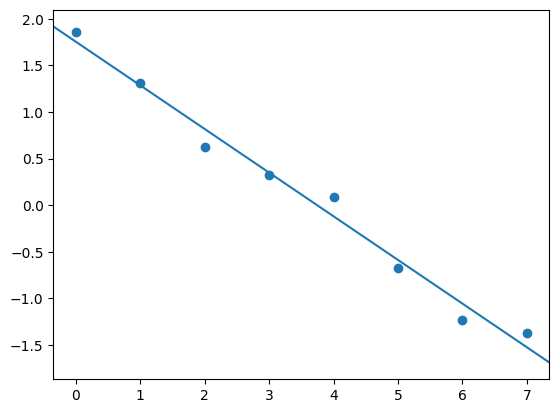

In [24]:
regression_plot(x, y, m, b)

In [25]:
m.item()

-0.4681258499622345

In [26]:
b.item()

1.7542961835861206

**N.B.**: The model doesn't perfectly approximate the slope (-0.5) and $y$-intercept (2.0) used to simulate the outcomes $y$ at the top of this notebook. This reflects the imperfectness of the sample of eight data points due to adding random noise during the simulation step. In the real world, the best solution would be to sample additional data points: The more data we sample, the more accurate our estimates of the true underlying parameters will be. 